In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [45]:
df = pd.read_pickle(Path(os.getcwd()).parent / "datos" / "intermedios" / "tablo_analitico_preparado.pkl")

In [46]:
df

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6259559.0
2020-05-15 00:00:00,p1,1IF53ai7Xc0U56Y,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6183645.0
2020-05-15 00:00:00,p1,3PZuoBAID5Wc2HD,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6987759.0
2020-05-15 00:00:00,p1,7JYdWkrLSPkdwr4,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7602960.0
2020-05-15 00:00:00,p1,McdE0feGgRqW7Ca,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7158964.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-17 23:45:00,p2,q49J1IKaHRwDQnt,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,100.0,0.0,4157.0,520758.0
2020-06-17 23:45:00,p2,rrq4fwE8jgrTyWY,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,100.0,0.0,3931.0,121131356.0
2020-06-17 23:45:00,p2,vOuJvMaM2sgwLmb,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,100.0,0.0,4322.0,2427691.0


In [47]:
captacion = df.loc[(df['id_inversor'] == '1BY6WEcLGh8j5v7') | (df['id_inversor'] == 'xMbIugepa2P7lBB'), 'id_planta': 'temperatura_modulo_c']

In [48]:
# Agrupar por id_planta y calcular medias
captacion_agg = captacion.groupby('id_planta').agg({
    'irradiacion_wh_m2': lambda x: x[x != 0].mean(),  # Media solo de valores diferentes a 0
    'temperatura_ambiente_c': 'mean',
    'temperatura_modulo_c': 'mean'
}).round(2)

captacion_agg

,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c
id_planta,,,
p1,0.41,25.56,31.18
p2,0.37,27.41,31.56


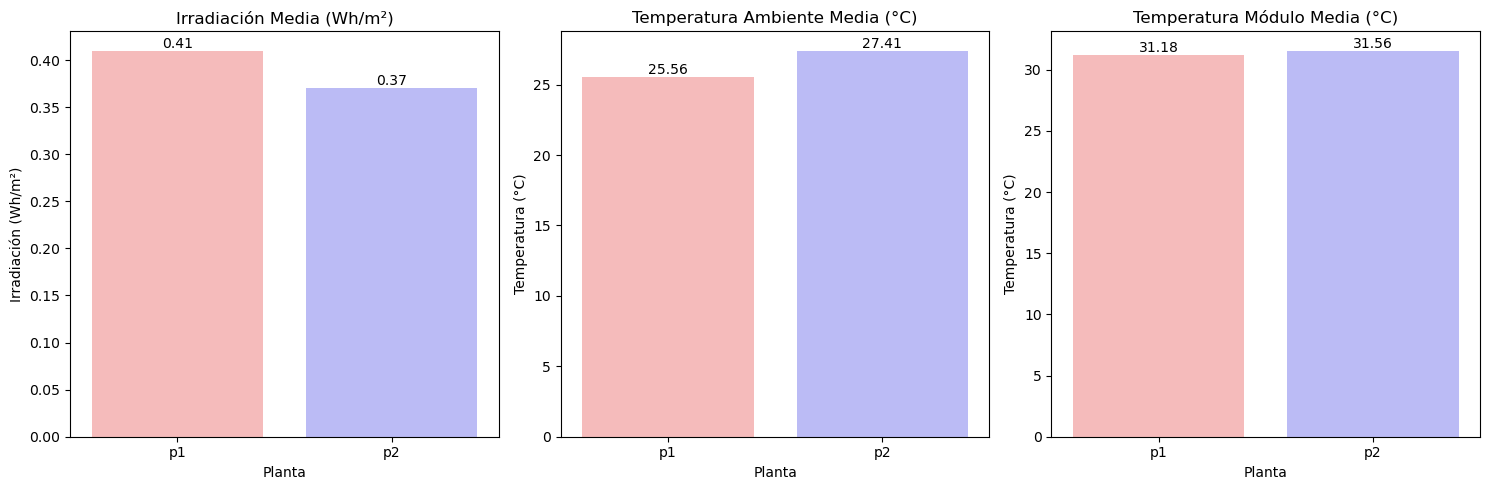

In [49]:
# Preparar datos para el gráfico
captacion_agg_reset = captacion_agg.reset_index()

# Configurar colores
colores = {'p1': 'red', 'p2': 'blue'}

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Irradiación
sns.barplot(data=captacion_agg_reset, x='id_planta', y='irradiacion_wh_m2', 
            hue='id_planta', palette=colores, alpha=0.3, ax=axes[0], legend=False)
axes[0].set_title('Irradiación Media (Wh/m²)')
axes[0].set_xlabel('Planta')
axes[0].set_ylabel('Irradiación (Wh/m²)')
# Añadir valores encima de las barras
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f')

# Gráfico 2: Temperatura Ambiente
sns.barplot(data=captacion_agg_reset, x='id_planta', y='temperatura_ambiente_c', 
            hue='id_planta', palette=colores, alpha=0.3, ax=axes[1], legend=False)
axes[1].set_title('Temperatura Ambiente Media (°C)')
axes[1].set_xlabel('Planta')
axes[1].set_ylabel('Temperatura (°C)')
# Añadir valores encima de las barras
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')

# Gráfico 3: Temperatura Módulo
sns.barplot(data=captacion_agg_reset, x='id_planta', y='temperatura_modulo_c', 
            hue='id_planta', palette=colores, alpha=0.3, ax=axes[2], legend=False)
axes[2].set_title('Temperatura Módulo Media (°C)')
axes[2].set_xlabel('Planta')
axes[2].set_ylabel('Temperatura (°C)')
# Añadir valores encima de las barras
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

## Insight #4: No existen problemas en la captación

### Descripción
Tras analizar los parámetros de captación solar de ambas plantas fotovoltaicas, **no se detectan anomalías significativas** que justifiquen pérdidas de rendimiento en esta fase del proceso.

### Evidencias
- **Irradiación solar**: Ambas plantas registran valores consistentes (P1: 0.41 Wh/m², P2: 0.37 Wh/m²), dentro del rango esperado para el periodo analizado.
- **Temperatura ambiente**: Los valores medios se encuentran en rangos normales (P1: 25.56°C, P2: 27.41°C).
- **Temperatura de módulos**: Ambas plantas muestran comportamiento térmico similar (P1: 31.18°C, P2: 31.56°C), sin indicios de sobrecalentamiento.

### Conclusión
Los sistemas de captación operan correctamente. **La investigación de posibles problemas de rendimiento debe centrarse en las fases posteriores**: conversión DC/AC (inversores), transmisión y acumulación energética.

In [50]:
captacion_corr = captacion[['id_planta','irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c']].select_dtypes(include='number').corr()

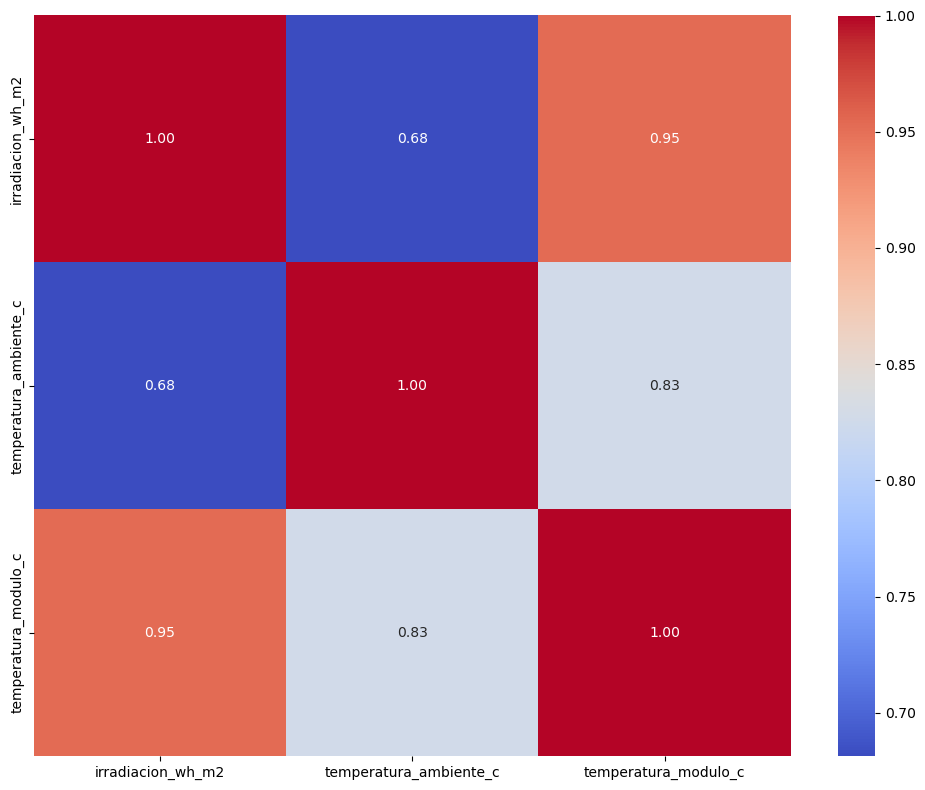

In [51]:
# Correlación en captación entre variables, irradiacion_wh_m2, temperatura_ambiente_c y temperatura_modulo_c con heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(captacion_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.tight_layout()
plt.show()


In [52]:
temp_pair = captacion[['id_planta','irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c']]

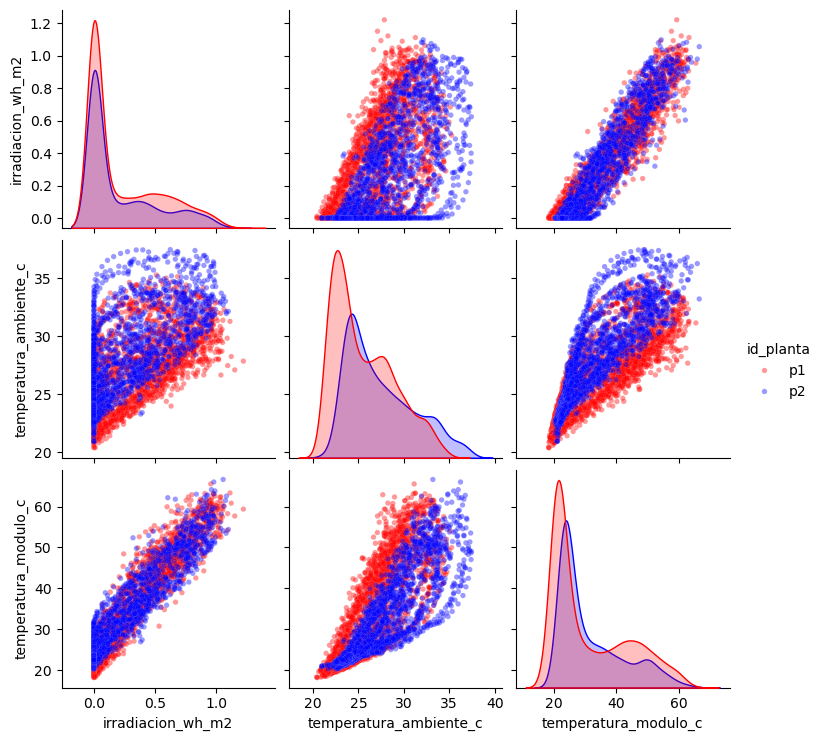

In [53]:
# crear un pairplot
sns.pairplot(temp_pair, hue='id_planta', palette=colores, 
             plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'white', 'linewidth': 0.1})

In [58]:
temp_hora_planta = pd.crosstab(
    captacion.reset_index()['hora'], 
    captacion.reset_index()['id_planta'], 
    values=captacion.reset_index()['irradiacion_wh_m2'], 
    aggfunc='sum'
)

In [59]:
temp_hora_planta

id_planta,p1,p2
hora,,
0,0.000000,0.000102
1,0.000000,0.000106
2,0.000000,0.000115
3,0.000000,0.000344
4,0.000000,0.000526
5,0.014891,0.023962
6,5.244716,3.709666
7,25.753335,16.302686
8,50.683759,33.394774


Text(120.72222222222221, 0.5, 'Hora')

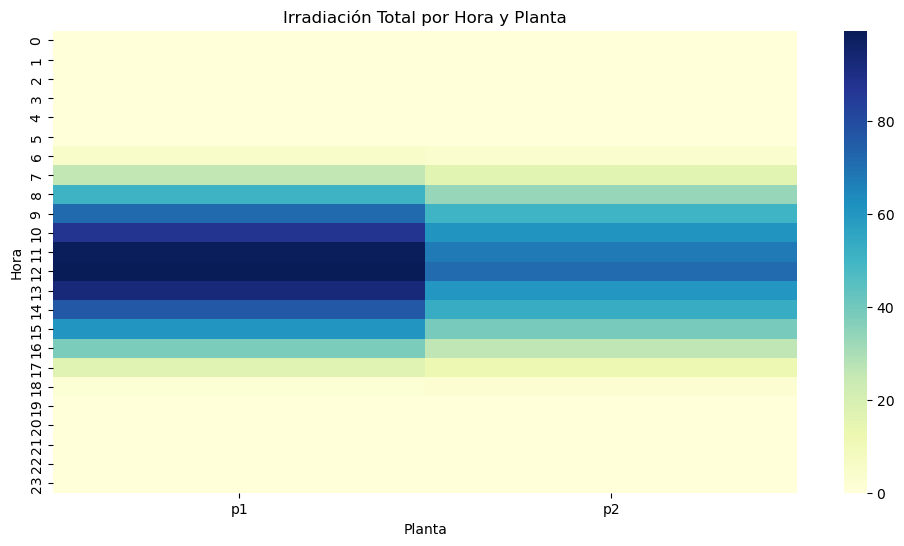

In [ ]:
# Heatmap sobre temp_hora_planta
plt.figure(figsize=(12, 6))
sns.heatmap(
    temp_hora_planta,
    cmap='magma',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    linecolor='white',
    yticklabels=[f'{h:02d}:00' for h in temp_hora_planta.index],
    cbar_kws={'label': 'Irradiación (Wh/m²)'}
)
plt.title('Irradiación Total por Hora y Planta')
plt.xlabel('Planta')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()